In [11]:
!pip install cellpose

In [12]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff
from cellpose import plot
from pathlib import Path
import pickle
import numpy as np
import os


class CalciumRecording:
    def __init__(self, path: str):
        self.data: np.ndarray = self._load(path)
        print(self.data.shape)
        self.path = path
        self.file_name = Path(path).name

    @staticmethod
    def _load_avi(path: str):
        cap = cv2.VideoCapture(path)

        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        cap.release()
        return np.array(frames)

    def _load(self, path: str):
        if "avi" in path:
            data = CalciumRecording._load_avi(path)
        else:
            data = tiff.imread(path)

        return data

    def save_results(self, masks, flows):
        np.save(f"masks+{self.file_name}.npy", masks)
        with open(f"flows+{self.file_name}.pkl", "wb") as f:
            pickle.dump(flows, f)

    def load_results():
        masks = np.load(f"masks+{self.file_name}.npy", allow_pickle=True)
        with open(f"flows+{self.file_name}.pkl", "rb") as f:
            flows = pickle.load(f)
        return masks, flows
    

    def visualize(self, masks: np.ndarray, flows: np.ndarray):
        from matplotlib.animation import FuncAnimation, FFMpegWriter
    
        fig = plt.figure(figsize=(20, 20))
    
        def update(t):
            fig.clf()
            plot.show_segmentation(fig, self.data[t], masks[t], flows[t][0])
    
        ani = FuncAnimation(fig, update, frames=self.data.shape[0], interval=100)
        writer = FFMpegWriter(fps=10)
        ani.save(f"segmentation+{self.file_name}.mp4", writer=writer)
        plt.close()
        print(f"Saved to segmentation+{self.file_name}.mp4")



In [14]:
from cellpose import models


class Segmenter:
    def __init__(self):
        pass

    @staticmethod
    def generate_mask(recording: CalciumRecording):
        model = models.CellposeModel(gpu=True)
        data = [recording.data[i] for i in range(recording.data.shape[0])]
        masks, flows, styles = model.eval(data, diameter=None, channels=[0, 0])
        return masks, flows


(360, 200, 214)


360
360
Saved to segmentation+6s.tif.mp4
(58, 1022, 369)


58
58
Saved to segmentation+Cropped Cb NLS gray.tif.mp4
(2160, 200, 210, 3)


2160
2160


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '2000x2000', '-pix_fmt', 'rgba', '-framerate', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'segmentation+Medien1.avi.mp4']' returned non-zero exit status 255.

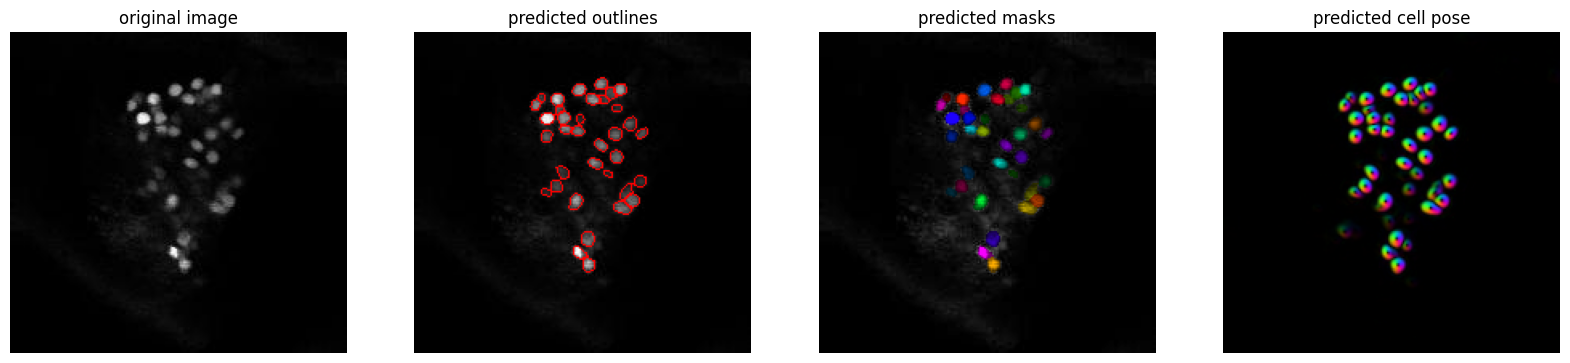

In [15]:
file_paths = [
    "/kaggle/input/datasets/mokarbalaee/neuroseg/6s.tif",
    "/kaggle/input/datasets/mokarbalaee/neuroseg/Cropped Cb NLS gray.tif",
    "/kaggle/input/datasets/mokarbalaee/neuroseg/Medien1.avi",
    "/kaggle/input/datasets/mokarbalaee/neuroseg/Medien2.avi",
    "/kaggle/input/datasets/mokarbalaee/neuroseg/NLS_6s_registered.tif"
]
for file_path in file_paths:
    recording: CalciumRecording = CalciumRecording(path=file_path)
    masks, flows = Segmenter.generate_mask(recording)
    recording.save_results(masks, flows)
    
    print(len(masks))
    print(len(flows))
    recording.visualize(masks, flows)